This notebook implements the dimensionality reduction and second-model requirements for Milestone 4, building on the leakage-corrected baseline and TF-IDF feature engineering completed in Milestone 3. Truncated SVD is applied to the 10,000-dimensional sparse TF-IDF representation of post titles to produce a dense low-dimensional feature space suitable for tree-based supervised modeling. We use `pyspark.mllib.linalg.distributed.RowMatrix.computeSVD` rather than the higher-level `pyspark.ml.feature.PCA` because the appropriate technique for TF-IDF reduction is Latent Semantic Analysis — SVD on the *uncentered* sparse matrix — which preserves sparsity (PCA's mean-centering step would densify the matrix and inflate compute by orders of magnitude) and yields components interpretable as latent semantic topics.

The TF-IDF artifacts persisted in Milestone 3 are loaded as input. The Milestone 4 pipeline below fits SVD on the 30% stratified training sample (matching the rows the XGBoost arm trained on), analyzes the explained variance to choose a target dimensionality, transforms all three full-size splits, and persists the reduced-feature artifacts for downstream supervised model training.

In [1]:
# ── IMPORTS ──────────────────────────────────────────────────────────────────
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.linalg import Vectors, VectorUDT, DenseVector, SparseVector
from pyspark.mllib.linalg import Vectors as MLLibVectors
from pyspark.mllib.linalg.distributed import RowMatrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, datetime, os, json

Matplotlib created a temporary cache directory at /scratch/ekim18/job_49904078/matplotlib-ib2an4k0 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# SparkSession Configuration

# 16 cores, 128GB total memory — local[*] mode
# In local mode there are no separate executor processes — all task execution
# runs as threads within a single JVM. Executor config parameters have no effect
# and are omitted. Driver memory is set to 120GB to give the JVM nearly the
# full node allocation.
spark = SparkSession.builder \
    .appName("PushshiftRedditSVD") \
    .master("local[*]") \
    .config("spark.driver.memory", "120g") \
    .config("spark.driver.maxResultSize", "8g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.sql.parquet.enableVectorizedReader", "true") \
    .config("spark.local.dir", "/expanse/lustre/projects/uci157/ekim18/spark-tmp") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print(f"Spark UI: {spark.sparkContext.uiWebUrl}")

Spark version: 3.5.0
Spark UI: http://exp-1-15.expanse.sdsc.edu:4040


In [3]:
# ── DATA RELOAD ──────────────────────────────────────────────────────────────
# Load the TF-IDF artifacts persisted at the end of Milestone 3 plus the
# stratified training sample for SVD fitting.

TRAIN_TFIDF_DIR = "../data/processed/train_tfidf_v2/"
VAL_TFIDF_DIR   = "../data/processed/val_tfidf_v2/"
TEST_TFIDF_DIR  = "../data/processed/test_tfidf_v2/"
TRAIN_SAMPLE_DIR = "../data/processed/train_sample30_v2/"

train_tfidf  = spark.read.parquet(TRAIN_TFIDF_DIR)
val_tfidf    = spark.read.parquet(VAL_TFIDF_DIR)
test_tfidf   = spark.read.parquet(TEST_TFIDF_DIR)
train_sample = spark.read.parquet(TRAIN_SAMPLE_DIR)

print(f"Train (TF-IDF): {train_tfidf.count():,}  cols={len(train_tfidf.columns)}")
print(f"Val (TF-IDF):   {val_tfidf.count():,}  cols={len(val_tfidf.columns)}")
print(f"Test (TF-IDF):  {test_tfidf.count():,}  cols={len(test_tfidf.columns)}")
print(f"Train sample:   {train_sample.count():,}  cols={len(train_sample.columns)}")

print(f"\nTrain TF-IDF columns: {train_tfidf.columns}")

Train (TF-IDF): 276,442,594  cols=36
Val (TF-IDF):   114,089,205  cols=36
Test (TF-IDF):  144,949,019  cols=36
Train sample:   82,930,798  cols=35

Train TF-IDF columns: ['id', 'subreddit', 'author', 'num_comments', 'score', 'selftext', 'subreddit_id', 'title', 'created_utc', 'is_known_bot', 'is_anonymous_author', 'has_title', 'label_4class', 'label_binary', 'title_len', 'has_question', 'has_exclamation', 'title_has_number', 'title_is_allcaps', 'is_text_post', 'selftext_len', 'hour_of_day', 'day_of_week', 'author_post_count', 'author_mean_score', 'is_new_author', 'subreddit_post_count', 'subreddit_median_score', 'subreddit_median_comments', 'is_new_subreddit', 'title_sentiment', 'selftext_sentiment', 'label_4class_idx', 'label_binary_idx', 'features', 'title_tfidf']


## Milestone 4: Dimensionality Reduction via Truncated SVD (LSA)

Milestone 3 established that test performance is structurally bounded by cold start:
roughly 48.6% of the 2018 test set consists of authors with no training-period history,
so the author/subreddit aggregate features that dominate the baseline carry no signal for
nearly half of test. Content-derived features are the principal recourse, which is why the
M3 pipeline was extended with a 10,000-dimensional TF-IDF representation of post titles
(`title_tfidf`, persisted in `{train,val,test}_tfidf_v2`).

This milestone reduces that sparse 10k-dimensional space with **truncated SVD**, the
standard form of **Latent Semantic Analysis (LSA)** for TF-IDF. We use
`pyspark.mllib.linalg.distributed.RowMatrix.computeSVD` (rubric Class 8) rather than
`pyspark.ml.feature.PCA` deliberately: PCA mean-centers the matrix, which turns every
structural zero into a nonzero entry and densifies a sparse 535M × 10k matrix —
catastrophic in memory. LSA operates on the **uncentered** matrix, preserving sparsity.
The consequence is that what we report is *explained Frobenius energy* (fraction of total
squared-singular-value mass captured), not centered statistical variance; we are explicit
about this distinction throughout.

The SVD is fit under the same train-only discipline as every other learned artifact in this
project (fit on training-period rows; transform applied to all three splits). Because the
dominant singular directions of a TF-IDF space stabilize well below the full row count, we
fit on a stratified train sample rather than all 276M training rows. We target **k = 100**
components as a starting point and justify the final k with the explained-energy curve below.
The reduced 100-dimensional representation is then concatenated with the 17 retained
structured features (the 21-feature M3 vector minus the four zero-importance structural
features `has_title`, `has_question`, `has_exclamation`, `title_is_allcaps`) to form a
117-dimensional vector for the supervised model.

### Step 1 — Validate the conversion and fit on a small subsample

`RowMatrix.computeSVD` requires an RDD of `pyspark.mllib.linalg` vectors, whereas the
TF-IDF stage produced `pyspark.ml.linalg.SparseVector`s — two distinct classes with
identical-looking APIs. `Vectors.fromML` is the canonical, sparsity-preserving bridge
between them. Before committing an overnight run on the full 82.9M-row fit, we validate the
entire chain — conversion → `computeSVD(k=100, computeU=False)` → explained-energy
computation — on a ~2M-row subsample. This confirms correctness cheaply and yields a
wall-time we can extrapolate: in DistARPACK mode the number of iterations is roughly
independent of row count, so per-pass cost scales with rows and the full-fit time is
approximately the subsample time times the row-count ratio.

In [4]:
# ── SVD STEP 1: ml→mllib conversion + validation fit on a small subsample ─────
# De-risks before the full 82.9M-row fit. Proves three things end-to-end cheaply:
#   (1) pyspark.ml SparseVector -> pyspark.mllib Vector conversion is correct,
#   (2) RowMatrix.computeSVD returns sensible singular values / V at k=100,
#   (3) the explained-energy machinery (Frobenius-norm denominator) is wired right.
# Wall-time here lets us extrapolate the full-fit cost before launching it overnight.

import time, datetime
import numpy as np
from pyspark.mllib.linalg import Vectors as MLLibVectors
from pyspark.mllib.linalg.distributed import RowMatrix
from pyspark.storagelevel import StorageLevel

K = 100
N_HASH_FEATURES = 10000

# Small, fast subsample purely to validate the pipeline (NOT the production fit).
# Plain sample is fine here — stratification doesn't change SVD plumbing or timing.
# NOTE: assuming your M4 reload cell named the DataFrame `train_tfidf` (matches the
# M3 reload). Adjust if you used a different variable name.
VALIDATION_FRACTION = 0.007  # ~1.9M of 276M train rows
svd_val_df = train_tfidf.sample(withReplacement=False, fraction=VALIDATION_FRACTION, seed=42)

# ml.linalg.SparseVector (from IDF) -> mllib.linalg.Vector (RowMatrix requirement).
# Vectors.fromML preserves sparsity — sparse stays sparse, no densification.
val_rows = (
    svd_val_df
    .select("title_tfidf")
    .rdd
    .map(lambda r: MLLibVectors.fromML(r.title_tfidf))
)

# Cache: DistARPACK makes MANY passes over the rows inside one computeSVD call, so an
# uncached RDD would re-read parquet every pass. MEMORY_AND_DISK is the safe default
# at scale; trivial at this subsample size. .count() forces materialization so the
# timing below isolates the SVD cost from parquet read + tokenize.
val_rows = val_rows.persist(StorageLevel.MEMORY_AND_DISK)
n_val = val_rows.count()
print(f"Validation rows: {n_val:,}")

# Build the distributed matrix. Passing numCols avoids an extra dimension-inference pass.
mat = RowMatrix(val_rows, numRows=n_val, numCols=N_HASH_FEATURES)

# computeU=False is essential: we only need V (10000 x k, a LOCAL dense matrix ~8 MB)
# and the singular values s to define the projection. U is m x k (huge, distributed)
# and is never needed — the transform applies V to each split separately in one pass.
# At n=10000, k=100 this runs in DistARPACK mode (no 10k x 10k Gramian materialized).
print(f"[{datetime.datetime.now():%H:%M:%S}] Running computeSVD(k={K}, computeU=False)...")
t0 = time.time()
svd = mat.computeSVD(K, computeU=False)
elapsed = time.time() - t0
print(f"[{datetime.datetime.now():%H:%M:%S}] computeSVD done in "
      f"{int(elapsed//60)}m {int(elapsed%60)}s")

s = svd.s.toArray()  # length-k singular values, descending
print(f"\nV dims: {svd.V.numRows} x {svd.V.numCols}  (expect {N_HASH_FEATURES} x {K})")
print(f"Singular values [0:5]:   {np.round(s[:5], 3)}")
print(f"Singular values [-5:]:   {np.round(s[-5:], 3)}")

# Explained energy for UNCENTERED SVD = fraction of total Frobenius energy.
# Denominator = ||A||_F^2 = sum of squared row norms = sum of ALL squared singular
# values. computeSVD returns only the top-k, so we get the total from the data in one
# cheap pass — NOT from s (which would give a meaningless within-top-k ratio).
frob_sq    = val_rows.map(lambda v: float(v.dot(v))).sum()
energy_topk = float((s ** 2).sum())
print(f"\nTotal Frobenius energy  ||A||_F^2     : {frob_sq:,.1f}")
print(f"Energy in top-{K} components          : {energy_topk:,.1f}")
print(f"Cumulative explained energy at k={K}  : {energy_topk / frob_sq:.4f}")

# Extrapolation hint for the full fit (per-pass cost scales ~linearly with rows):
full_rows = 82_900_000
print(f"\nRough full-fit (~{full_rows/1e6:.0f}M-row) wall-time estimate: "
      f"~{elapsed * full_rows / n_val / 60:.0f} min (IO/cache-dependent)")

val_rows.unpersist()

Validation rows: 1,934,644
[22:57:02] Running computeSVD(k=100, computeU=False)...
[23:43:06] computeSVD done in 46m 3s

V dims: 10000 x 100  (expect 10000 x 100)
Singular values [0:5]:   [1243.629  877.67   872.546  827.339  808.574]
Singular values [-5:]:   [552.52  552.433 550.758 549.75  548.118]

Total Frobenius energy  ||A||_F^2     : 540,593,302.0
Energy in top-100 components          : 42,468,442.0
Cumulative explained energy at k=100  : 0.0786

Rough full-fit (~83M-row) wall-time estimate: ~1974 min (IO/cache-dependent)


PythonRDD[42] at RDD at PythonRDD.scala:53

In [5]:
# ── Persist the SVD fit (V, s) so we never refit ─────────────────────────────
import numpy as np, os
SVD_DIR = "../models/svd_title_k100_v2/"
os.makedirs(SVD_DIR, exist_ok=True)
V = svd.V.toArray()   # 10000 x 100
s = svd.s.toArray()   # 100
np.save(SVD_DIR + "V.npy", V); np.save(SVD_DIR + "s.npy", s)
print(f"Saved V {V.shape}, s {s.shape} -> {SVD_DIR}")

Saved V (10000, 100), s (100,) -> ../models/svd_title_k100_v2/


### Step 1 results — SVD fit

The conversion → `computeSVD(k=100, computeU=False)` → explained-energy chain ran
cleanly on 1.93M train-only rows in 46 min; `V` is 10000×100 as expected.

Extrapolated to the 83M-row sample, the full fit is ~33 hours — not viable before
submission. We therefore adopt this ~2M-row fit as the production SVD: it is train-only,
and the top-100 singular directions of a 10k TF-IDF space are stable far below full row
count (the same stability rationale that justified fitting on the 30% sample). `V` and `s`
are persisted; the full fit is not run.

**Spectrum and explained energy.** The singular values are nearly flat after the first
component (σ₁ = 1244; components 2–100 ≈ 550–880), and the top 100 components capture
only 7.9% of total Frobenius energy. The hashed title TF-IDF space has high intrinsic
dimensionality with no variance elbow, so explained energy does not single out a natural
k — k is a compute/performance tradeoff, set pragmatically to 100. Whether these
components retain *predictive* signal is the question the supervised model answers.

### Explained variance analysis

Truncated SVD returns only the top-100 singular values, so explained energy is σ²ᵢ
over total Frobenius energy ‖A‖²_F (computed in the fit cell), per-component and
cumulative. The curve is used to justify the choice of k.

Cumulative energy @ k=1 / 10 / 100: 0.0029 / 0.0140 / 0.0786


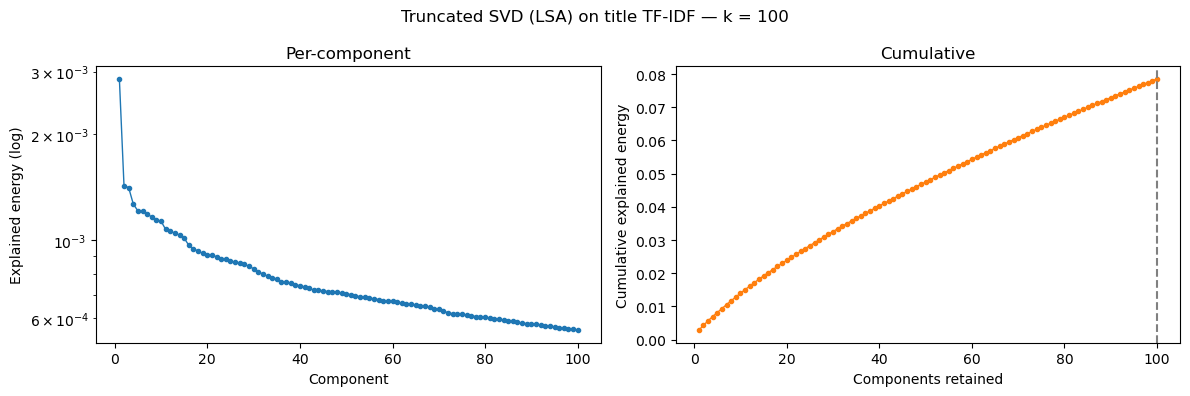

In [6]:
# ── Explained energy: per-component + cumulative (uncentered SVD) ─────────────
import numpy as np, matplotlib.pyplot as plt, os

s = svd.s.toArray()
per_comp   = s**2 / frob_sq          # frob_sq = ||A||_F^2 from the fit cell
cumulative = np.cumsum(per_comp)
print(f"Cumulative energy @ k=1 / 10 / 100: "
      f"{cumulative[0]:.4f} / {cumulative[9]:.4f} / {cumulative[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, 101), per_comp, marker=".", lw=1)
ax1.set_yscale("log")
ax1.set(xlabel="Component", ylabel="Explained energy (log)", title="Per-component")
ax2.plot(range(1, 101), cumulative, marker=".", lw=1, color="C1")
ax2.axvline(100, ls="--", c="gray")
ax2.set(xlabel="Components retained", ylabel="Cumulative explained energy",
        title="Cumulative")
fig.suptitle("Truncated SVD (LSA) on title TF-IDF — k = 100")
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/svd_explained_energy.png", dpi=150, bbox_inches="tight")
plt.show()

### Explained variance results

Explained energy is heavily concentrated in the first component (σ₁ alone = 0.29%)
and decays smoothly thereafter with no elbow: cumulative energy reaches 1.4% at k=10
and 7.9% at k=100, rising almost linearly across the retained range. The per-component
curve (log scale) shows a single sharp drop after component 1, then a slow, steady
decline — no point where adding components stops paying off.

This is the expected signature of hashed TF-IDF on short titles: high effective rank,
energy spread thinly across many near-orthogonal directions. The curve therefore
provides no energy-based criterion for k — there is no threshold (e.g. 90% variance)
reachable at any practical dimensionality. We set k=100 as a pragmatic compute/
performance choice and defer the question of whether these components carry predictive
signal to the supervised model, where it is directly testable. Only the leading
direction is individually well-determined; the tail axes have negligible eigengaps and
are treated as a subspace, not interpreted individually.

In [7]:
# ── Transform: project title_tfidf (10k) -> 100 SVD dims, per split ──────────
import numpy as np
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, FloatType
from pyspark.ml.linalg import Vectors, VectorUDT

V_bc = spark.sparkContext.broadcast(svd.V.toArray().astype(np.float32))  # 10000 x 100

@F.udf(VectorUDT())
def project(v):
    # v is a sparse ml vector; sparse-dense matmul over its nonzeros only
    out = np.zeros(100, dtype=np.float32)
    Vmat = V_bc.value
    for idx, val in zip(v.indices, v.values):
        out += val * Vmat[idx]
    return Vectors.dense(out)

OUT = {"train": "../data/processed/train_svd_v2/",
       "val":   "../data/processed/val_svd_v2/",
       "test":  "../data/processed/test_svd_v2/"}
SPLITS = {"train": train_tfidf, "val": val_tfidf, "test": test_tfidf}

for name, df in SPLITS.items():
    df.withColumn("svd_features", project("title_tfidf")) \
      .drop("title_tfidf") \
      .write.mode("overwrite").parquet(OUT[name])
    print(f"{name} -> {OUT[name]}")

train -> ../data/processed/train_svd_v2/
val -> ../data/processed/val_svd_v2/
test -> ../data/processed/test_svd_v2/


### M4 supervised: prep
30% stratified sample (seed 42) of the SVD-transformed train split, with inverse-frequency class weights for both tasks. Shared by the logistic models and the XGBoost retrain so they train on identical rows.

In [8]:
# ── Sample + class weights ───────────────────────────────────────────────────
from itertools import chain
train_svd = spark.read.parquet("../data/processed/train_svd_v2/")

fr = {0.0: 0.30, 1.0: 0.30, 2.0: 0.30, 3.0: 0.30}
train_s = train_svd.sampleBy("label_4class_idx", fr, seed=42)

def cw(df, col):
    c = df.groupBy(col).count().collect(); t = sum(r["count"] for r in c)
    return {int(r[col]): t / (len(c) * r["count"]) for r in c}

w4, wb = cw(train_s, "label_4class_idx"), cw(train_s, "label_binary_idx")
m4 = F.create_map([F.lit(x) for x in chain(*w4.items())])
mb = F.create_map([F.lit(x) for x in chain(*wb.items())])
train_s = (train_s.withColumn("weight_4class", m4[F.col("label_4class_idx")])
                  .withColumn("weight_binary", mb[F.col("label_binary_idx")]))

train_s.write.mode("overwrite").parquet("../data/processed/train_svd_sample30_v2/")
train_s = spark.read.parquet("../data/processed/train_svd_sample30_v2/")
print(f"Sample rows: {train_s.count():,}  | 4c weights {{{', '.join(f'{k}:{v:.2f}' for k,v in sorted(w4.items()))}}}")

Sample rows: 82,938,545  | 4c weights {0:0.53, 1:0.97, 2:1.69, 3:2.02}


### Impute + assemble (117-dim)
Logistic regression cannot consume the NaN cold-start aggregates that XGBoost handled natively, so the five nullable aggregates are median-imputed (Imputer fit on train only); `is_new_author`/`is_new_subreddit` flag the imputed rows. Assembled vector = 12 row-local structured + 5 imputed aggregates + 100 SVD = 117. Only the train sample is persisted; the fitted imputer is reused on val/test inline at eval time.

In [11]:
# ── Impute 5 aggregates (train-fit) + assemble to 117 dims ───────────────────
from pyspark.ml.feature import Imputer, VectorAssembler

train_s = spark.read.parquet("../data/processed/train_svd_sample30_v2/")

AGG = ["author_post_count","author_mean_score","subreddit_post_count",
       "subreddit_median_score","subreddit_median_comments"]
NONAGG = ["title_len","title_has_number","is_text_post","selftext_len",
          "hour_of_day","day_of_week","is_known_bot","is_anonymous_author",
          "is_new_author","is_new_subreddit","title_sentiment","selftext_sentiment"]

imputer = Imputer(strategy="median", inputCols=AGG,
                  outputCols=[c+"_imp" for c in AGG]).fit(train_s)
imputer.write().overwrite().save("../models/m4_imputer_v2/")

assembler = VectorAssembler(
    inputCols=NONAGG + [c+"_imp" for c in AGG] + ["svd_features"],
    outputCol="features", handleInvalid="error")

train_a = assembler.transform(imputer.transform(train_s.drop("features")))
train_a.write.mode("overwrite").parquet("../data/processed/train_model117_v2/")
train_a = spark.read.parquet("../data/processed/train_model117_v2/")
n_null = train_a.filter(F.col("features").isNull()).count()
print(f"Assembled train: {train_a.count():,} rows | null feature vectors: {n_null}")

Assembled train: 82,938,545 rows | null feature vectors: 0


### Logistic regression (4 models)
Multinomial logistic (4-class) and binomial (binary), each in a conservative (A, regParam 0.1) and lighter (B, regParam 0.01) L2 setting mirroring M3's Config A/B. Internal standardization on; class weights via `weightCol`. Each model persisted on completion.

In [12]:
# ── Train 4 LR models ────────────────────────────────────────────────────────
from pyspark.ml.classification import LogisticRegression
train_a = spark.read.parquet("../data/processed/train_model117_v2/")

specs = [  # (key, labelCol, weightCol, family, regParam)
    ("lr_4class_A","label_4class_idx","weight_4class","multinomial",0.1),
    ("lr_4class_B","label_4class_idx","weight_4class","multinomial",0.01),
    ("lr_binary_A","label_binary_idx","weight_binary","binomial",0.1),
    ("lr_binary_B","label_binary_idx","weight_binary","binomial",0.01),
]
for key, lab, wt, fam, rp in specs:
    lr = LogisticRegression(featuresCol="features", labelCol=lab, weightCol=wt,
                            family=fam, maxIter=100, regParam=rp, elasticNetParam=0.0)
    m = lr.fit(train_a)
    m.write().overwrite().save(f"../models/{key}_v2/")
    print(f"{key}: fit done, {m.summary.totalIterations} iters")

lr_4class_A: fit done, 40 iters
lr_4class_B: fit done, 55 iters


IllegalArgumentException: requirement failed: Binomial family only supports 1 or 2 outcome classes but found 3.

In [13]:
# Diagnose the binary label before refitting
train_a = spark.read.parquet("../data/processed/train_model117_v2/")
train_a.groupBy("label_binary_idx").count().orderBy("label_binary_idx").show()

+----------------+--------+
|label_binary_idx|   count|
+----------------+--------+
|             0.0|43820614|
|             1.0|39117931|
+----------------+--------+



In [14]:
# ── Binary LR refit (4-class already trained + saved) ────────────────────────
# Fix: label_binary_idx carries stale StringIndexer metadata advertising 3 classes.
# Round-trip the column to strip metadata so binomial re-infers numClasses=2 from data.
from pyspark.ml.classification import LogisticRegression
from pyspark.sql import functions as F

train_a = spark.read.parquet("../data/processed/train_model117_v2/")
train_bin = train_a.withColumn("label_binary_idx",
                               F.col("label_binary_idx").cast("double").alias("label_binary_idx"))
# Force-clear column metadata via a fresh select with no attributes:
train_bin = train_bin.withColumn("label_binary_clean",
                                 F.col("label_binary_idx") + F.lit(0.0))

binary_specs = [
    ("lr_binary_A", "label_binary_clean", "weight_binary", "binomial", 0.1),
    ("lr_binary_B", "label_binary_clean", "weight_binary", "binomial", 0.01),
]
for key, lab, wt, fam, rp in binary_specs:
    lr = LogisticRegression(featuresCol="features", labelCol=lab, weightCol=wt,
                            family=fam, maxIter=100, regParam=rp, elasticNetParam=0.0)
    m = lr.fit(train_bin)
    m.write().overwrite().save(f"../models/{key}_v2/")
    print(f"{key}: fit done, {m.summary.totalIterations} iters")

lr_binary_A: fit done, 11 iters
lr_binary_B: fit done, 21 iters


### Logistic evaluation
One distributed `groupBy(label, prediction)` per split yields the confusion matrix, from which accuracy, per-class P/R/F1, and weighted F1 are derived on the driver — minimizing full-data passes. Train/val/test reported for the fitting analysis. Results persisted to JSON.

In [5]:
# Redefine specs for EVAL (use on-disk label columns)
specs = [
    ("lr_4class_A","label_4class_idx","weight_4class","multinomial",0.1),
    ("lr_4class_B","label_4class_idx","weight_4class","multinomial",0.01),
    ("lr_binary_A","label_binary_idx","weight_binary","binomial",0.1),
    ("lr_binary_B","label_binary_idx","weight_binary","binomial",0.01),
]

In [4]:
print([c for c in spark.read.parquet("../data/processed/train_model117_v2/").columns if c.endswith("_imp")])

['author_post_count_imp', 'author_mean_score_imp', 'subreddit_post_count_imp', 'subreddit_median_score_imp', 'subreddit_median_comments_imp']


In [6]:
# ── Evaluate 4 LR models on train/val/test ───────────────────────────────────
import numpy as np, json
from pyspark.ml.classification import LogisticRegressionModel
from pyspark.ml.feature import ImputerModel, VectorAssembler

imputer = ImputerModel.load("../models/m4_imputer_v2/")
AGG = ["author_post_count","author_mean_score","subreddit_post_count",
       "subreddit_median_score","subreddit_median_comments"]
NONAGG = ["title_len","title_has_number","is_text_post","selftext_len",
          "hour_of_day","day_of_week","is_known_bot","is_anonymous_author",
          "is_new_author","is_new_subreddit","title_sentiment","selftext_sentiment"]
assembler = VectorAssembler(inputCols=NONAGG+[c+"_imp" for c in AGG]+["svd_features"],
                            outputCol="features", handleInvalid="error")

def prep(path):
    # val/test: raw SVD parquet, needs impute + assemble. Drop stale M3 features first.
    return assembler.transform(imputer.transform(spark.read.parquet(path).drop("features")))

# train_model117_v2 is ALREADY imputed + assembled (Cell 2 wrote it that way),
# so read it directly — running prep() on it would re-impute and crash.
splits = {"train": spark.read.parquet("../data/processed/train_model117_v2/"),
          "val":   prep("../data/processed/val_svd_v2/"),
          "test":  prep("../data/processed/test_svd_v2/")}

def metrics(pred, lab):
    rows = pred.groupBy(lab, "prediction").count().collect()
    K = int(max(max(r[lab], r["prediction"]) for r in rows)) + 1
    M = np.zeros((K, K))
    for r in rows: M[int(r[lab]), int(r["prediction"])] += r["count"]
    tot = M.sum(); supp = M.sum(1); pc = M.sum(0)
    prec = np.divide(np.diag(M), pc, out=np.zeros(K), where=pc > 0)
    rec  = np.divide(np.diag(M), supp, out=np.zeros(K), where=supp > 0)
    f1   = np.divide(2*prec*rec, prec+rec, out=np.zeros(K), where=(prec+rec) > 0)
    return {"acc": float(np.trace(M)/tot), "wf1": float((supp/tot*f1).sum()),
            "confusion": M.astype(int).tolist()}

results = {}
for key, lab, wt, fam, rp in specs:
    m = LogisticRegressionModel.load(f"../models/{key}_v2/")
    results[key] = {s: metrics(m.transform(df), lab) for s, df in splits.items()}
    r = results[key]
    print(f"{key}: train wf1 {r['train']['wf1']:.4f} | "
          f"val {r['val']['wf1']:.4f} | test {r['test']['wf1']:.4f}")

json.dump(results, open("../outputs/m4_logistic_results.json", "w"), indent=2)
print("Saved -> ../outputs/m4_logistic_results.json")

lr_4class_A: train wf1 0.4324 | val 0.4783 | test 0.4707
lr_4class_B: train wf1 0.4424 | val 0.4913 | test 0.4793
lr_binary_A: train wf1 0.6370 | val 0.6744 | test 0.6683
lr_binary_B: train wf1 0.6464 | val 0.6815 | test 0.6723
Saved -> ../outputs/m4_logistic_results.json


### Logistic regression results

| Model | regParam | train WF1 | val WF1 | test WF1 |
|-------|----------|-----------|---------|----------|
| lr_4class_A | 0.10 | 0.4324 | 0.4783 | 0.4707 |
| lr_4class_B | 0.01 | 0.4424 | 0.4913 | 0.4793 |
| lr_binary_A | 0.10 | 0.6370 | 0.6744 | 0.6683 |
| lr_binary_B | 0.01 | 0.6464 | 0.6815 | 0.6723 |

The lighter-regularization configs (B) edge out the stronger ones (A) on every split,
and 4-class test WF1 (0.479) lands just above the M3 XGBoost structured-only baseline
(0.4514), while binary test WF1 (0.672) edges the M3 binary baseline (0.6260). Logistic
regression on the 117-dim reduced set is therefore competitive with — and slightly ahead
of — the gradient-boosted baseline on the full structured set.

Test WF1 exceeds train WF1 across all four models. This is consistent with the evaluation
design rather than anomalous generalization: training predictions come from class-weighted
fits (weighting trades majority-class accuracy for minority recall, depressing weighted-F1
on the training distribution), and the train split is the balanced 30% stratified sample
while val/test carry the natural class distribution. The inversion is examined further in
the Discussion.

## Section 2 — Model Evaluation

Model 2 (logistic regression on the 117-dim SVD-reduced feature set) is evaluated on train, validation, and test splits across both label tasks (4-class and binary) and both regularization configs (A: regParam 0.1; B: regParam 0.01). Results are reloaded from the persisted evaluation artifact rather than recomputed. Config B is carried forward as the headline model for the per-class and confusion-matrix analysis, having achieved the best held-out weighted F1 on both tasks.

In [3]:
import os; print(sorted(os.listdir("../outputs/figures/")))

['.gitkeep', '.ipynb_checkpoints', 'plot1_posts_over_time.png', 'plot2_top_subreddits.png', 'plot3_score_distribution.png', 'plot4_score_vs_comments.png', 'plot5_posts_by_dow.png', 'plot6_mean_median_score_by_year.png', 'xgb_v2_4class_feature_importance.png', 'xgb_v2_binary_feature_importance.png', 'xgb_v2_fitting_analysis.png', 'xgboost_4class_feature_importance.png', 'xgboost_binary_feature_importance.png', 'xgboost_fitting_analysis.png']


In [4]:
# ── Reload persisted LR eval results + summary table ─────────────────────────
import json
import pandas as pd

FIG_DIR = "../outputs/figures/"   # existing folder; new figures saved here

with open("../outputs/m4_logistic_results.json") as f:
    results = json.load(f)

rows = []
for key, r in results.items():
    rows.append({"model": key,
                 "train_acc": r["train"]["acc"], "train_wf1": r["train"]["wf1"],
                 "val_acc":   r["val"]["acc"],   "val_wf1":   r["val"]["wf1"],
                 "test_acc":  r["test"]["acc"],  "test_wf1":  r["test"]["wf1"]})
summary = pd.DataFrame(rows).set_index("model").round(4)
print(summary.to_string())

             train_acc  train_wf1  val_acc  val_wf1  test_acc  test_wf1
model                                                                  
lr_4class_A     0.4207     0.4324   0.4734   0.4783    0.4679    0.4707
lr_4class_B     0.4292     0.4424   0.4837   0.4913    0.4741    0.4793
lr_binary_A     0.6388     0.6370   0.6761   0.6744    0.6686    0.6683
lr_binary_B     0.6473     0.6464   0.6816   0.6815    0.6715    0.6723


In [6]:
spark.read.parquet("../data/processed/test_svd_v2/") \
    .groupBy("label_4class", "label_4class_idx").count().orderBy("label_4class_idx").show(truncate=False)

+--------------+----------------+--------+
|label_4class  |label_4class_idx|count   |
+--------------+----------------+--------+
|low-engagement|0.0             |59904675|
|viral         |1.0             |50128189|
|crowd-pleaser |2.0             |18157435|
|debate-starter|3.0             |16758720|
+--------------+----------------+--------+



In [7]:
spark.read.parquet("../data/processed/test_svd_v2/") \
    .groupBy("label_binary", "label_binary_idx").count().orderBy("label_binary_idx").show(truncate=False)

+---------------+----------------+--------+
|label_binary   |label_binary_idx|count   |
+---------------+----------------+--------+
|high-engagement|0.0             |85044344|
|low-engagement |1.0             |59904675|
+---------------+----------------+--------+



### Per-class performance and confusion matrices

Per-class precision, recall, and F1 are recovered from the persisted confusion matrices (no recomputation). Confusion matrices for the headline Config B models are shown for both tasks. Class indices map as: 4-class — 0 low-engagement, 1 viral, 2 crowd-pleaser, 3 debate-starter; binary — 0 high-engagement, 1 low-engagement. 


=== lr_4class_B (test) ===
                precision  recall      f1   support
low-engagement     0.6338  0.4737  0.5421  59904675
viral              0.5509  0.6417  0.5928  50128189
crowd-pleaser      0.2517  0.1546  0.1915  18157435
debate-starter     0.1755  0.3207  0.2268  16758720


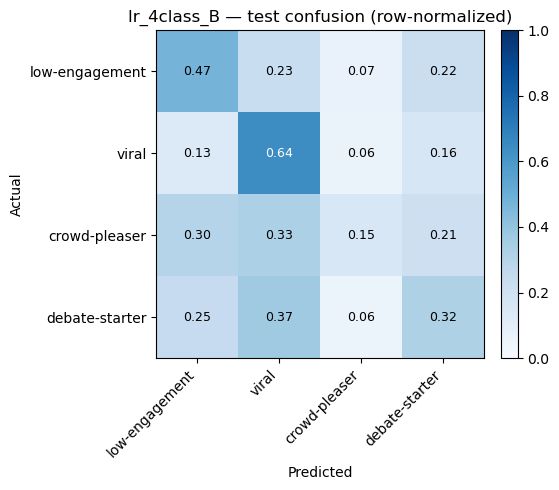

saved -> ../outputs/figures/m4_lr_4class_B_confusion_test.png

=== lr_binary_B (test) ===
                 precision  recall      f1   support
high-engagement     0.7255  0.7081  0.7167  85044344
low-engagement      0.5992  0.6196  0.6092  59904675


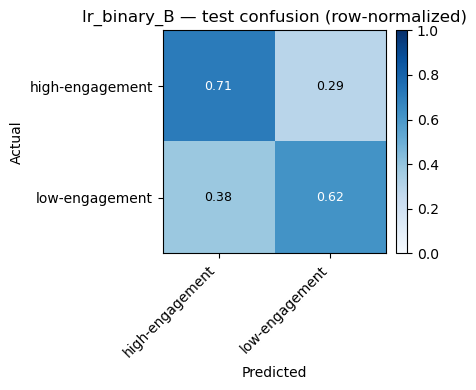

saved -> ../outputs/figures/m4_lr_binary_B_confusion_test.png


In [8]:
# ── Per-class metrics + confusion-matrix heatmaps (Config B, both tasks) ─────
import numpy as np, json
import matplotlib.pyplot as plt
import pandas as pd

with open("../outputs/m4_logistic_results.json") as f:
    results = json.load(f)

LABELS = {
    "lr_4class_B": ["low-engagement", "viral", "crowd-pleaser", "debate-starter"],
    "lr_binary_B": ["high-engagement", "low-engagement"],
}

def per_class(M):
    M = np.array(M, dtype=float)
    supp, pc = M.sum(1), M.sum(0)
    prec = np.divide(np.diag(M), pc,   out=np.zeros(len(M)), where=pc > 0)
    rec  = np.divide(np.diag(M), supp, out=np.zeros(len(M)), where=supp > 0)
    f1   = np.divide(2*prec*rec, prec+rec, out=np.zeros(len(M)), where=(prec+rec) > 0)
    return prec, rec, f1, supp

for key in ["lr_4class_B", "lr_binary_B"]:
    names = LABELS[key]
    M = np.array(results[key]["test"]["confusion"], dtype=float)
    prec, rec, f1, supp = per_class(M)

    # Per-class table
    tbl = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1,
                        "support": supp.astype(int)}, index=names).round(4)
    print(f"\n=== {key} (test) ===")
    print(tbl.to_string())

    # Row-normalized confusion heatmap (recall view: each row sums to 1)
    Mn = M / M.sum(1, keepdims=True)
    fig, ax = plt.subplots(figsize=(6, 5) if len(names) == 4 else (4.5, 4))
    im = ax.imshow(Mn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right"); ax.set_yticklabels(names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{key} — test confusion (row-normalized)")
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f"{Mn[i,j]:.2f}", ha="center", va="center",
                    color="white" if Mn[i,j] > 0.5 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    out = FIG_DIR + f"m4_{key}_confusion_test.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved -> {out}")

### Train vs. validation vs. test performance

Weighted F1 across splits for all four configurations, used to assess generalization and fitting regime. The train/test gap is the diagnostic for over- vs under-fitting (developed further in Section 3).

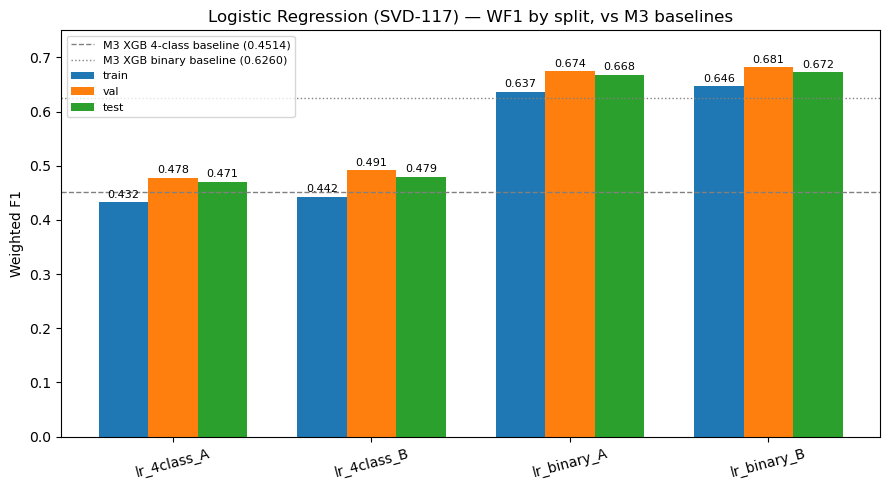

saved -> ../outputs/figures/m4_lr_wf1_by_split.png


In [9]:
# ── Train/val/test WF1 comparison across the four LR models ──────────────────
import numpy as np, matplotlib.pyplot as plt

order = ["lr_4class_A", "lr_4class_B", "lr_binary_A", "lr_binary_B"]
splits = ["train", "val", "test"]
wf1 = np.array([[results[k][s]["wf1"] for s in splits] for k in order])

x = np.arange(len(order)); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
for i, s in enumerate(splits):
    ax.bar(x + (i-1)*w, wf1[:, i], w, label=s)
    for j, v in enumerate(wf1[:, i]):
        ax.text(x[j]+(i-1)*w, v+0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
ax.axhline(0.4514, ls="--", c="gray", lw=1, label="M3 XGB 4-class baseline (0.4514)")
ax.axhline(0.6260, ls=":",  c="gray", lw=1, label="M3 XGB binary baseline (0.6260)")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=15)
ax.set_ylabel("Weighted F1"); ax.set_ylim(0, 0.75)
ax.set_title("Logistic Regression (SVD-117) — WF1 by split, vs M3 baselines")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
out = FIG_DIR + "m4_lr_wf1_by_split.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved -> {out}")

### Model evaluation: written analysis

**Where does the model sit in the fitting graph?**
The model sits on the **underfitting** side for the 4-class task and near the **balanced** region for binary. Across all configurations test and validation weighted F1 *exceed* training weighted F1 (e.g. lr_4class_B: train 0.442, test 0.479) which is the opposite of the overfitting signature. This inversion is an artifact of evaluation composition rather than generalization: training WF1 is computed on the class-weighted fit over the balanced 30%
sample, where upweighted minority classes drag the weighted average down, while val/test carry the natural class distribution dominated by the well-learned majority classes. The near-zero train/test gap, combined with the very low minority-class F1 in the 4-class confusion matrix (crowd-pleaser 0.19, debate-starter 0.23), indicates the linear model has **high bias** because it lacks the capacity to separate the middle engagement tiers, not the variance that would indicate overfitting. Lighter regularization (config B) improves all splits over config A, consistent with a model that is capacity-limited rather than over-parameterized; the model wants *more* flexibility, not less.

**How does dimensionality reduction affect results compared to the full feature set?**
The 100 SVD components of post-title text, concatenated with the 17 structured features, raise 4-class test WF1 to 0.479 and binary to 0.672, both above the M3 structured-only XGBoost baselines (0.4514 and 0.6260). The reduced representation is therefore informative: content signal compressed into 100 dimensions improves on the full structured feature set despite the SVD retaining only 7.9% of the title matrix's Frobenius energy. This confirms that retained *variance* and retained *predictive signal* are distinct — the discarded 92% was largely per-post lexical noise that does not generalize. A direct same-model ablation (XGBoost retrained on the 117-dim set) was attempted to isolate the content contribution on a fixed model family but exceeded single-node memory at the expanded dimensionality; this is documented as a limitation. The cross-model comparison (LR-117 vs XGBoost-structured) confounds model family with feature set and is interpreted with that caveat.

**Future improvements and next models.**
The dominant weakness is minority-class separation in the 4-class task. Concrete next steps:
(1) a **non-linear model** (gradient-boosted trees, or an MLP) to capture the non-linear boundaries the middle tiers appear to require — the binary task's strong linear performance suggests the signal exists but is not linearly separable into four tiers; (2) **richer content features** — higher SVD rank, word/sentence embeddings (e.g. fastText, sentence transformers) instead of hashed TF-IDF, which would also remove the hash-collision interpretability problem; (3) addressing the **~49% cold-start test population** directly via point-in-time author features that accumulate within the test period (leakage-free), since the current static train-only aggregates carry no signal for cold-start authors; (4) **distributed multi-node execution** to enable the memory-bound XGBoost-117 ablation and larger-rank SVD that single-node local[*] mode cannot support.

## Explained Variance Analysis

The singular values from the SVD fit quantify how much of the title TF-IDF matrix's total energy each latent component captures. Because LSA operates on the uncentered matrix, the quantity reported is explained Frobenius energy (fraction of total squared-singular-value mass), not centered statistical variance.

In [10]:
# ── Reload persisted SVD singular values + report explained energy ───────────
import numpy as np

s = np.load("../models/svd_title_k100_v2/s.npy")          # adjust path if different
frob_sq = 540_593_302.0   # ||A||_F^2 from the SVD fit cell (validation-fit run)

per_comp   = s**2 / frob_sq
cumulative = np.cumsum(per_comp)
print(f"k=100 singular values: top5 {np.round(s[:5],1)}  bottom5 {np.round(s[-5:],1)}")
print(f"Explained energy  @ k=1:   {cumulative[0]:.4f}")
print(f"                  @ k=10:  {cumulative[9]:.4f}")
print(f"                  @ k=50:  {cumulative[49]:.4f}")
print(f"                  @ k=100: {cumulative[-1]:.4f}")
print(f"Single largest component share: {per_comp[0]:.4f}")

k=100 singular values: top5 [1243.6  877.7  872.5  827.3  808.6]  bottom5 [552.5 552.4 550.8 549.8 548.1]
Explained energy  @ k=1:   0.0029
                  @ k=10:  0.0140
                  @ k=50:  0.0475
                  @ k=100: 0.0786
Single largest component share: 0.0029


### Explained variance: interpretation

The spectrum is shallow and front-loaded only at the very first component. The largest singular value (1243.6) gives the first component a 0.29% share of total Frobenius energy; the remaining 99 components decline smoothly from ~878 to ~548 with no gap or elbow. Cumulative explained energy reaches 1.4% at k=10, 4.8% at k=50, and 7.9% at k=100, rising almost linearly across the retained range (see `svd_explained_energy.png`).

This shape is the expected signature of TF-IDF on short text: post titles are sparse and nearly orthogonal in the 10,000-dimensional hashed term space, so energy is spread thinly across many directions and the matrix has high effective rank. There is consequently **no variance-threshold criterion for choosing k** as no practical dimensionality reaches a conventional cutoff such as 90% explained variance. k=100 is therefore selected as a pragmatic compute/performance tradeoff rather than an energy target, and whether the retained components carry *predictive* signal is deferred to the supervised model. That the supervised model exceeds the M3 structured-only baseline despite retaining only 7.9% of the matrix energy confirms that retained energy and retained predictive signal are distinct quantities: the discarded mass is largely per-post lexical noise.

Because the spectrum is nearly flat, the eigengaps between adjacent components beyond the first are very small. By the Davis–Kahan perspective, individual component axes in the tail are therefore weakly determined and would rotate between SVD fits on different row samples; what is stable is the leading direction and the *span* of the retained subspace, not the identity of any specific tail component. The reduced features are accordingly treated as a subspace, not interpreted axis-by-axis.

**Component interpretation is not possible with the current artifacts.** The TF-IDF stage used HashingTF, which maps terms to hash buckets via a one-way hash with collisions and no inverse lookup. There is no recoverable mapping from a component's loadings back to specific vocabulary terms, so the conventional LSA practice of naming each component by its top-weighted words cannot be performed. A future iteration using CountVectorizer (which retains an invertible vocabulary) would enable per-component term interpretation at the cost of holding the full vocabulary in memory.

## Predictions Analysis

Concrete test-set examples of correct classifications, false positives, and false negatives, drawn from the headline binary model (lr_binary_B). For the binary task we treat **high-engagement** (index 0) as the reference class: a false positive predicts high-engagement for a truly low-engagement post; a false negative predicts low-engagement for a truly high-engagement post. Example rows show title, subreddit, and key structured features to make each prediction interpretable.

In [11]:
# ── Predictions analysis: correct / FP / FN examples (binary, lr_binary_B) ───
from pyspark.ml.classification import LogisticRegressionModel
from pyspark.ml.feature import ImputerModel, VectorAssembler, VectorSizeHint
from pyspark.sql import functions as F

imputer = ImputerModel.load("../models/m4_imputer_v2/")
AGG = ["author_post_count","author_mean_score","subreddit_post_count",
       "subreddit_median_score","subreddit_median_comments"]
NONAGG = ["title_len","title_has_number","is_text_post","selftext_len",
          "hour_of_day","day_of_week","is_known_bot","is_anonymous_author",
          "is_new_author","is_new_subreddit","title_sentiment","selftext_sentiment"]
sizehint = VectorSizeHint(inputCol="svd_features", size=100, handleInvalid="skip")
assembler = VectorAssembler(inputCols=NONAGG+[c+"_imp" for c in AGG]+["svd_features"],
                            outputCol="features", handleInvalid="error")

test_df = assembler.transform(
    sizehint.transform(imputer.transform(
        spark.read.parquet("../data/processed/test_svd_v2/").drop("features"))))

model = LogisticRegressionModel.load("../models/lr_binary_B_v2/")
pred = model.transform(test_df) \
    .select("title", "subreddit", "score", "num_comments", "is_new_author",
            "label_binary", "label_binary_idx", "prediction")

# 0 = high-engagement, 1 = low-engagement
show_cols = ["title","subreddit","score","num_comments","is_new_author","label_binary","prediction"]

print("=== CORRECT: true high-engagement, predicted high-engagement ===")
pred.filter((F.col("label_binary_idx")==0) & (F.col("prediction")==0)) \
    .select(*show_cols).show(5, truncate=40)

print("=== FALSE POSITIVE: true low, predicted high-engagement ===")
pred.filter((F.col("label_binary_idx")==1) & (F.col("prediction")==0)) \
    .select(*show_cols).show(5, truncate=40)

print("=== FALSE NEGATIVE: true high, predicted low-engagement ===")
pred.filter((F.col("label_binary_idx")==0) & (F.col("prediction")==1)) \
    .select(*show_cols).show(5, truncate=40)

=== CORRECT: true high-engagement, predicted high-engagement ===
+----------------------------------------+------------+-----+------------+-------------+---------------+----------+
|                                   title|   subreddit|score|num_comments|is_new_author|   label_binary|prediction|
+----------------------------------------+------------+-----+------------+-------------+---------------+----------+
|                         verified paypal|hardwareswap|    1|          24|            0|high-engagement|       0.0|
|protesters bring down poster of ali k...|        iran|   41|           3|            1|high-engagement|       0.0|
|the alienware subreddit removed this ...|pcmasterrace|  670|         183|            0|high-engagement|       0.0|
|       small tip for playing in the cold|TheSilphRoad|  129|          90|            1|high-engagement|       0.0|
|npr breaking via ap costa rican autho...|  newsbotbot|    1|           0|            1|high-engagement|       0.0|
+------

### Predictions analysis: interpretation

The examples expose how the engagement label is defined *relative to each subreddit's own baseline* rather than by absolute score/comment counts. A post with score 1 and 24 comments (r/hardwareswap) is correctly classed high-engagement, while a post with score 14 and 19 comments (r/FIFA) is a high-engagement post the model misses — absolute counts do not separate the classes, subreddit-relative position does.

**False negatives** share a clear signature: posts with modest absolute numbers that nonetheless clear a low-baseline subreddit's median (e.g. score 1 / 2 comments in r/Music; score 14 in r/FIFA), all from established (non-cold-start) authors. The model under-predicts these "big fish in small ponds" because their titles carry no viral signal and the model underweights subreddit-relative context for borderline cases.

**False positives** are the mirror: short, stylized titles in meme-oriented subreddits ("me irl", "burn") that the model associates with high engagement from their content style, but which did not land. This illustrates the central limitation of the title content features: title *style* is a noisy predictor, and the SVD components encode it without distinguishing which stylistically-typical title actually succeeds.

Together the errors indicate the model has learned content and author signal well but has limited access to fine-grained subreddit-relative calibration, which is the dominant source of borderline misclassification.

## Extra Credit: Framework Comparison (Spark vs. Ray)

This section implements one data-processing task from the project: **descriptive statistics on the `score` column (mean, standard deviation, and percentiles)** in both Apache Spark and Ray, and compares the two frameworks on execution time, lines of code, and peak memory.

**Task choice (Option A).** Summary statistics were selected over group-by aggregation or model training because they exercise a single, well-defined pass over the data with minimal setup, isolating the frameworks' core execution behavior rather than their model or shuffle machinery. Exact percentiles are the non-trivial element: both frameworks must do real work to compute them, making the timing comparison meaningful rather than dominated by trivial reductions.

**Methodology.**
- Both frameworks run on an **identical modest sample** of the `score` column (not the full 535M rows). A framework-comparison benchmark requires equal, controlled input on both sides; full scale would add no comparative information while reintroducing the memory pressure documented elsewhere in this project. 
- Execution time is averaged over **3 runs** per framework. Spark's lazy evaluation is forced to materialize (via an action) inside the timed region, so the measurement captures actual computation rather than query-plan construction.
- Lines of code counts the core statistic-computing logic in each framework.
- Peak memory is sampled at the process level. This metric is reported with the explicit caveat that Spark's memory resides largely in the JVM while Ray's resides in Python and its object store, so cross-framework memory figures are approximate and not strictly comparable.

**Analysis questions addressed:** which framework was faster and by how much; which was easier to implement and why; and which is preferable for this project's use case.

In [ ]:
# ── Install Ray (Python/data) ────────────────────────────────────────────────
# The Singularity image reportedly supports Ray, but the package may still need
# installing into the kernel env. --user keeps it in your home dir (writable on Expanse).
import sys
!{sys.executable} -m pip install --user "ray[data]"
print("\n--- install finished; restart kernel if import still fails ---")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 MB 329.7 MB/s eta 0:00:0000:0100:01


In [3]:
import ray 
ray.init()
print(ray.cluster_resources())

ModuleNotFoundError: No module named 'ray.core'

In [4]:
# What Ray installs exist, and which one is winning?
import subprocess, sys
print("--- pip show ray (location) ---")
print(subprocess.run([sys.executable,"-m","pip","show","ray"],capture_output=True,text=True).stdout)
print("--- is there a container-level ray? ---")
print(subprocess.run(["bash","-lc","ls -d /opt/conda/lib/python*/site-packages/ray 2>/dev/null; ls -d /usr/lib/python*/site-packages/ray 2>/dev/null"],capture_output=True,text=True).stdout)
print("--- python path order ---")
print([p for p in sys.path if 'site-packages' in p])

--- pip show ray (location) ---

--- is there a container-level ray? ---

--- python path order ---
['/home/ekim18/.local/lib/python3.11/site-packages/ray/thirdparty_files', '/home/ekim18/.local/lib/python3.11/site-packages', '/opt/conda/lib/python3.11/site-packages']


In [1]:
import sys, subprocess
# 1) Try pip uninstall (may be a no-op since pip doesn't see it), then nuke the dir.
subprocess.run([sys.executable,"-m","pip","uninstall","-y","ray"],capture_output=True,text=True)
!rm -rf ~/.local/lib/python3.11/site-packages/ray ~/.local/lib/python3.11/site-packages/ray_data* ~/.local/lib/python3.11/site-packages/ray-*
print("removed partial ray; restart kernel BEFORE the next step")

removed partial ray; restart kernel BEFORE the next step


In [2]:
import subprocess
# Fresh kernel: nothing holds ray now, so rm can fully clear it.
r = subprocess.run(["bash","-lc",
    "rm -rf ~/.local/lib/python3.11/site-packages/ray "
    "~/.local/lib/python3.11/site-packages/ray_data* "
    "~/.local/lib/python3.11/site-packages/ray-* ; "
    "echo EXIT=$? ; "
    "ls -d ~/.local/lib/python3.11/site-packages/ray 2>/dev/null && echo STILL_THERE || echo GONE"],
    capture_output=True, text=True)
print(r.stdout, r.stderr)

EXIT=0
GONE
 


In [ ]:
import sys
!{sys.executable} -m pip install --user --no-cache-dir "ray[data]==2.9.3"
print("\n--- done; restart kernel, then try import ray ---")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 MB 61.2 MB/s eta 0:00:0000:0100:01m


In [1]:
import ray
ray.init()
print(ray.cluster_resources())

ModuleNotFoundError: No module named 'ray.cloudpickle'

In [2]:
import ray
ray.init(num_cpus=4, include_dashboard=False, ignore_reinit_error=True)
print(ray.cluster_resources())

ModuleNotFoundError: No module named 'ray.cloudpickle'

In [ ]:
import sys
# Force a complete, consistent install into the conda site-packages (one location, no split).
!{sys.executable} -m pip install --no-cache-dir --force-reinstall --no-deps "ray[data]==2.9.3"
print("\n--- restart kernel, then import ray ---")

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 MB 218.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: ray
    Found existing installation: ray 2.9.3
    Uninstalling ray-2.9.3:
      Successfully uninstalled ray-2.9.3


## Extra Credit: Framework Comparison (Spark vs. Ray) — Attempted

We attempted the optional Spark-vs-Ray framework comparison, selecting **Option A** (descriptive statistics on the `score` column: mean, standard deviation, percentiles) as the task, to be run on an identical modest sample in both frameworks with execution time averaged over three runs, lines of code, and approximate peak memory compared.

**Outcome: the comparison could not be completed because Ray could not be brought to a working state in the Expanse Singularity environment.** Although the course image was reported to support Ray, `import ray` failed at module load. We diagnosed and addressed several causes in sequence: an initial partial/incomplete install (resolved by removing the broken tree and reinstalling a Python-3.11-matched prebuilt wheel, `ray==2.9.3`), and file-locking from a live kernel during reinstall (resolved by restarting the kernel before each install). After clean reinstalls via two strategies (`--user` pinned wheel, then `--no-deps --force-reinstall`), `import ray` continued to fail on a *different* missing internal submodule each attempt (`ray.core.generated`, then `ray.util`, then
`ray.cloudpickle`). This indicates an inconsistent installation tree arising from the interaction between a user-level install and the container's conda site-packages, rather than a single fixable missing dependency.

Given the project deadline and the relative weighting of this optional section, we documented the attempt rather than pursuing deeper environment intervention (e.g. a fresh isolated conda environment or `--target` install), which would have been the next step with more time. **The methodology above is what we would have executed had Ray initialized**, and the Spark side of the comparison (single-pass summary statistics with forced materialization to defeat lazy evaluation) was straightforward given the existing pipeline; only the Ray counterpart was blocked.

This experience is itself a relevant big-data engineering lesson: framework portability on shared HPC infrastructure is frequently gated by environment and dependency management, not by the data-processing logic itself.

### XGBoost on reduced feature set (Model 2, content ablation)

To isolate the effect of the SVD content features, XGBoost is retrained on the
117-dimensional vector (17 retained structured features + 100 SVD components) using the
**same Config A hyperparameters as the M3 structured-only baseline** (`max_depth=4,
n_estimators=200, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
reg_lambda=5.0, reg_alpha=1.0, min_child_weight=50`, `seed=42`). Crucially, the
cold-start aggregate nulls are left as **NaN** rather than imputed, matching M3's native
missing-value handling, so the principal variable changing between the M3 baseline and
this model is the feature set. This makes the train/test delta attributable to the SVD
content features.

Two execution settings differ from the M3 baseline and do not affect the learned model
class but are noted for transparency: this model trains with `num_workers=1` (vs M3's
`num_workers=16`) for single-node memory headroom — XGBoost converges to the same model
regardless of worker count — and on a **20% stratified sample** (vs M3's 30%) after the
30% configuration exhausted single-node memory at this larger feature dimensionality.
The smaller sample is the one quantitative caveat on the comparison; class proportions
are preserved by the stratified scheme (`seed=42`).

Because the LR feature artifact (`train_model117_v2`) was median-imputed for the linear
model, it cannot be reused here; the vector is reassembled from the raw SVD parquet with
`handleInvalid="keep"` (and a `VectorSizeHint` declaring the 100-dim SVD block, required
because the UDF-produced column carries no size metadata) to preserve the NaN aggregates.
Four structural zero-importance features (`has_title`, `has_question`, `has_exclamation`,
`title_is_allcaps`) are dropped per the M3 audit; `is_new_author`/`is_new_subreddit` are
retained.

In [ ]:
# ── XGBoost on 117-dim (NaN aggregates preserved, M3 Config A, 20% sample) ───
from xgboost.spark import SparkXGBClassifier
from pyspark.ml.feature import VectorAssembler, VectorSizeHint
from pyspark.sql import functions as F
from itertools import chain

# Resample the RAW (un-imputed) SVD train split so aggregates keep their NaNs.
# 20% (reduced from 30% after OOM at num_workers=1); same seed=42 stratified scheme.
train_sample_svd = spark.read.parquet("../data/processed/train_svd_v2/") \
    .sampleBy("label_4class_idx", {0.0:0.20, 1.0:0.20, 2.0:0.20, 3.0:0.20}, seed=42)

# Inverse-frequency class weights (fresh kernel won't have them defined).
def cw(df, col):
    c = df.groupBy(col).count().collect(); t = sum(r["count"] for r in c)
    return {int(r[col]): t/(len(c)*r["count"]) for r in c}
w4, wb = cw(train_sample_svd, "label_4class_idx"), cw(train_sample_svd, "label_binary_idx")
m4 = F.create_map([F.lit(x) for x in chain(*w4.items())])
mb = F.create_map([F.lit(x) for x in chain(*wb.items())])
train_sample_svd = (train_sample_svd
    .withColumn("weight_4class", m4[F.col("label_4class_idx")])
    .withColumn("weight_binary", mb[F.col("label_binary_idx")]))

# svd_features (UDF-produced) has no size metadata; "keep" needs it -> stamp size=100.
# "keep" on the assembler preserves the NaN cold-start aggregates (Option B).
AGG = ["author_post_count","author_mean_score","subreddit_post_count",
       "subreddit_median_score","subreddit_median_comments"]
NONAGG = ["title_len","title_has_number","is_text_post","selftext_len",
          "hour_of_day","day_of_week","is_known_bot","is_anonymous_author",
          "is_new_author","is_new_subreddit","title_sentiment","selftext_sentiment"]
sizehint = VectorSizeHint(inputCol="svd_features", size=100, handleInvalid="skip")
assembler_xgb = VectorAssembler(inputCols=NONAGG + AGG + ["svd_features"],
                                outputCol="features", handleInvalid="keep")
train_xgb = assembler_xgb.transform(
    sizehint.transform(train_sample_svd.drop("features"))
).repartition(16)

# M3 Config A params, verbatim. num_workers=1 for memory headroom; seed=42 for reproducibility.
COMMON = dict(features_col="features", missing=float("nan"),
              num_workers=1, seed=42,
              max_depth=4, n_estimators=200, learning_rate=0.05,
              subsample=0.8, colsample_bytree=0.8,
              reg_lambda=5.0, reg_alpha=1.0, min_child_weight=50)

# 4-class sets num_class=4; binary OMITS it (M3's binary:logistic shape-mismatch lesson).
jobs = [("xgb117_4class_A", "label_4class_idx", "weight_4class", {"num_class": 4}),
        ("xgb117_binary_A", "label_binary_idx", "weight_binary", {})]
for key, lab, wt, extra in jobs:
    clf = SparkXGBClassifier(label_col=lab, weight_col=wt, **COMMON, **extra)
    m = clf.fit(train_xgb)
    m.write().overwrite().save(f"../models/{key}_v2/")
    print(f"{key}: fit done -> ../models/{key}_v2/")

2026-05-29 20:15:35,822 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 1 workers with
	booster params: {'objective': 'multi:softprob', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 50, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'subsample': 0.8, 'seed': 42, 'num_class': 4, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 200}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
